### 4 · LangGraph RAG Flow — CMS3 Debugging Assistant

This notebook builds the first end-to-end LangGraph pipeline for the CMS3 log-debugging use case.

### Graph
```
START → classify_question → [retrieve] → retrieve_docs → rerank_docs → generate_answer → END
                          → [rewrite]  → rewrite_question → retrieve_docs → rerank_docs → generate_answer → END
```

- `classify_question` decides whether the query is standalone or a follow-up
- `rewrite_question` turns follow-ups into standalone debugging questions
- `retrieve_docs` searches Pinecone using business-aware filters like `customer_id`
- `rerank_docs` uses FlashRank to keep the strongest evidence
- `generate_answer` writes a grounded answer from the reranked logs


In [11]:
import json
import os
import re
from pathlib import Path
from typing import Annotated

from dotenv import load_dotenv
from flashrank import Ranker
from langchain_community.document_compressors import FlashrankRerank
from langchain_core.documents import Document
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from langgraph.graph import END, MessagesState, StateGraph
from pinecone import Pinecone

# Load environment variables from the project root.
NOTEBOOK_DIR = Path.cwd()
load_dotenv(dotenv_path=NOTEBOOK_DIR.parent / ".env", override=True)

EMBEDDING_MODEL = "text-embedding-3-small"
CLASSIFIER_MODEL = "gpt-4o-mini"
ANSWER_MODEL = "gpt-4o"
INDEX_NAME = os.getenv("PINECONE_INDEX_NAME", "move-mind-ai")
INDEX_HOST = os.getenv("PINECONE_INDEX_HOST")
NAMESPACE = os.getenv("PINECONE_NAMESPACE", "cms3-logs")
host_label = INDEX_HOST if INDEX_HOST else "<not set>"

required_env = ["OPENAI_API_KEY", "PINECONE_API_KEY"]
missing = [key for key in required_env if not os.getenv(key)]
if missing:
    raise ValueError(f"Missing required environment variables: {missing}")

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
index = pc.Index(host=INDEX_HOST) if INDEX_HOST else pc.Index(INDEX_NAME)
vectorstore = PineconeVectorStore(index=index, embedding=embeddings, namespace=NAMESPACE)
classifier_llm = ChatOpenAI(model=CLASSIFIER_MODEL, temperature=0)
answer_llm = ChatOpenAI(model=ANSWER_MODEL, temperature=0)
reranker = FlashrankRerank(client=Ranker(model_name="ms-marco-TinyBERT-L-2-v2"))

print(f"Connected to Pinecone index: {INDEX_NAME}")
print(f"Namespace: {NAMESPACE}")
print(f"Host override: {host_label}")


Connected to Pinecone index: move-mind-ai
Namespace: cms3-logs
Host override: https://move-mind-ai-g57210f.svc.aped-4627-b74a.pinecone.io


---
### Step 1 — Define the Shared State

The notebook follows the same idea as the app: messages live in graph state, and retrieved documents are stored in a serialization-safe structure.


In [12]:
import operator


class GraphState(MessagesState):
    question: str
    query_type: str
    documents: Annotated[list[dict], operator.add]
    reranked_documents: Annotated[list[dict], operator.add]
    answer: str


def doc_to_dict(doc: Document) -> dict:
    return {"page_content": doc.page_content, "metadata": dict(doc.metadata)}


def dict_to_doc(data: dict) -> Document:
    return Document(page_content=data["page_content"], metadata=data.get("metadata", {}))


def format_docs(doc_dicts: list[dict]) -> str:
    rendered = []
    for item in doc_dicts:
        metadata = item.get("metadata", {})
        rendered.append(
            f"[chunk_type={metadata.get('chunk_type', '?')} | "
            f"cid={metadata.get('customer_id', '?')} | "
            f"page={metadata.get('page_path', '?')}]\n"
            f"{item['page_content']}"
        )
    return "\n\n---\n\n".join(rendered)


print("Graph state and document helpers ready.")


Graph state and document helpers ready.


---
### Step 2 — Retrieval Helpers

Before the graph nodes run, we need small helpers that understand debugging questions and turn them into Pinecone filters.


In [13]:
CID_PATTERN = re.compile(r"\bCID\s*[:#-]?\s*(\d+)\b", re.IGNORECASE)
PAGE_PATTERN = re.compile(r"(/[A-Za-z0-9._/-]+)")


def extract_customer_id(query: str) -> str | None:
    match = CID_PATTERN.search(query)
    return match.group(1) if match else None


def extract_page_path(query: str) -> str | None:
    match = PAGE_PATTERN.search(query)
    return match.group(1) if match else None


def build_scope_filter(question: str) -> dict | None:
    metadata_filter = {}
    customer_id = extract_customer_id(question)
    page_path = extract_page_path(question)

    if customer_id:
        metadata_filter["customer_id"] = customer_id
    if page_path:
        metadata_filter["page_path"] = page_path

    return metadata_filter or None


def hybrid_retrieve(question: str, *, k_summary: int = 2, k_events: int = 8) -> list[Document]:
    base_filter = build_scope_filter(question) or {}

    summary_filter = {"chunk_type": "execution_summary"}
    if "customer_id" in base_filter:
        summary_filter["customer_id"] = base_filter["customer_id"]

    event_filter = {"chunk_type": "event", **base_filter}

    summary_docs = vectorstore.similarity_search(question, k=k_summary, filter=summary_filter)
    event_docs = vectorstore.similarity_search(question, k=k_events, filter=event_filter)

    unique = []
    seen = set()
    for doc in summary_docs + event_docs:
        key = (doc.page_content, json.dumps(doc.metadata, sort_keys=True, default=str))
        if key in seen:
            continue
        seen.add(key)
        unique.append(doc)
    return unique


print("Retrieval helpers ready.")


Retrieval helpers ready.


---
### Step 3 — Define the Nodes

These node functions mirror the app structure but stay readable enough for notebook exploration.


In [14]:
CLASSIFY_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "You are a query classifier. Decide if the user question is a standalone debugging request or a follow-up that depends on prior chat history. "
     "Respond with ONLY one word: retrieve or rewrite."),
    ("placeholder", "{chat_history}"),
    ("human", "{question}"),
])

REWRITE_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "Rewrite the follow-up question as a standalone CMS3 debugging question. "
     "Keep customer IDs, route paths, and flow context explicit. Respond with ONLY the rewritten question."),
    ("placeholder", "{chat_history}"),
    ("human", "{question}"),
])

ANSWER_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "You are a CMS3 debugging assistant for the Admin Tool. Answer based ONLY on the provided logs. "
     "If the logs do not contain enough evidence, say so clearly. Focus on customer IDs, routes, conditions, and concrete evidence.\n\nContext:\n{context}"),
    ("placeholder", "{chat_history}"),
    ("human", "{question}"),
])


def classify_question(state: GraphState) -> dict:
    chain = CLASSIFY_PROMPT | classifier_llm | StrOutputParser()
    result = chain.invoke({"question": state["question"], "chat_history": state.get("messages", [])}).strip().lower()
    if result not in {"retrieve", "rewrite"}:
        result = "retrieve"
    print(f"  [classify] → {result}")
    return {"query_type": result}


def rewrite_question(state: GraphState) -> dict:
    chain = REWRITE_PROMPT | classifier_llm | StrOutputParser()
    rewritten = chain.invoke({"question": state["question"], "chat_history": state.get("messages", [])}).strip()
    print(f"  [rewrite] → {rewritten}")
    return {"question": rewritten}


def retrieve_docs(state: GraphState) -> dict:
    docs = hybrid_retrieve(state["question"])
    print(f"  [retrieve] → {len(docs)} candidates")
    return {"documents": [doc_to_dict(doc) for doc in docs]}


def rerank_docs(state: GraphState) -> dict:
    docs = [dict_to_doc(item) for item in state.get("documents", [])]
    if not docs:
        print("  [rerank] → no candidates, skipping rerank")
        return {"reranked_documents": []}
    reranked = reranker.compress_documents(docs, state["question"])
    print(f"  [rerank] → {len(docs)} to {len(reranked)}")
    return {"reranked_documents": [doc_to_dict(doc) for doc in reranked]}


def generate_answer(state: GraphState) -> dict:
    context_docs = state.get("reranked_documents") or state.get("documents", [])
    context = format_docs(context_docs)
    chain = ANSWER_PROMPT | answer_llm | StrOutputParser()
    answer = chain.invoke({
        "question": state["question"],
        "context": context,
        "chat_history": state.get("messages", []),
    })
    print(f"  [generate] → {len(answer)} chars")
    return {
        "answer": answer,
        "messages": [HumanMessage(content=state["question"]), AIMessage(content=answer)],
    }


print("Graph nodes ready.")


Graph nodes ready.


---
### Step 4 — Build the Graph

The routing function creates the rewrite branch only when the classifier says the question depends on prior chat history.


In [15]:
def route_after_classify(state: GraphState) -> str:
    return state["query_type"]


workflow = StateGraph(GraphState)
workflow.add_node("classify_question", classify_question)
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("retrieve_docs", retrieve_docs)
workflow.add_node("rerank_docs", rerank_docs)
workflow.add_node("generate_answer", generate_answer)

workflow.set_entry_point("classify_question")
workflow.add_conditional_edges(
    "classify_question",
    route_after_classify,
    {"retrieve": "retrieve_docs", "rewrite": "rewrite_question"},
)
workflow.add_edge("rewrite_question", "retrieve_docs")
workflow.add_edge("retrieve_docs", "rerank_docs")
workflow.add_edge("rerank_docs", "generate_answer")
workflow.add_edge("generate_answer", END)

graph = workflow.compile()
print("Graph compiled.")


Graph compiled.


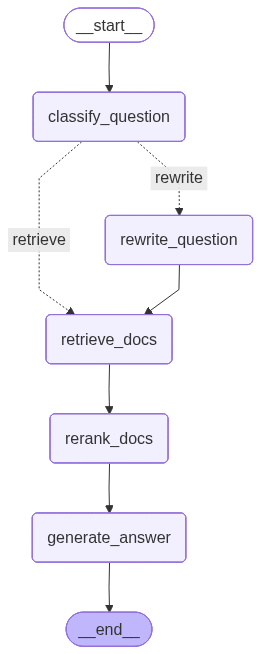

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


---
### Step 5 — Test Standalone Questions

These are the first-pass questions we expect from the Admin Tool chat interface.


In [17]:
question = "For CID 7093495, what happened after /ccflownew/move-scope?"
print(f"Question: {question}\n")
result = graph.invoke({"question": question})

print(f"\nQuery type: {result['query_type']}")
print(f"Retrieved docs: {len(result.get('documents', []))}")
print(f"Reranked docs: {len(result.get('reranked_documents', []))}")
print("\nANSWER")
print("=" * 100)
print(result["answer"])


Question: For CID 7093495, what happened after /ccflownew/move-scope?



INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [classify] → retrieve


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


  [retrieve] → 8 candidates
  [rerank] → 8 to 3


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [generate] → 481 chars

Query type: retrieve
Retrieved docs: 8
Reranked docs: 3

ANSWER
After the route /ccflownew/move-scope, the customer with CID 7093495 proceeded through the following routes:

1. /ccflownew/check-ist-flow
2. /ccflownew/conditions
3. /ccflownew/next
4. /ccflownew/items
5. /ccflownew/junk-option
6. /ccflownew/junk-normal-or-labour-check
7. /ccflownew/pitch
8. /ccflownew/quote
9. /ccflownew/quote/pricing
10. /ccflownew/quote/conditions
11. /ccflownew/quote/booking

This sequence is based on the route path provided in the execution summary logs.


In [18]:
question = "For CID 7093495, which UI condition evaluated to true on /ccflownew/quote/booking?"
print(f"Question: {question}\n")
result = graph.invoke({"question": question})

print(f"\nQuery type: {result['query_type']}")
print(f"Retrieved docs: {len(result.get('documents', []))}")
print(f"Reranked docs: {len(result.get('reranked_documents', []))}")
print("\nANSWER")
print("=" * 100)
print(result["answer"])


Question: For CID 7093495, which UI condition evaluated to true on /ccflownew/quote/booking?



INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [classify] → retrieve


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


  [retrieve] → 6 candidates
  [rerank] → 6 to 3


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [generate] → 113 chars

Query type: retrieve
Retrieved docs: 6
Reranked docs: 3

ANSWER
For CID 7093495, the UI condition that evaluated to true on the page /ccflownew/quote/booking was "true == true".


---
### Step 6 — Test a Follow-Up Path

Here we manually pass chat history so the classifier can choose the rewrite branch and the rewriter can produce a standalone debugging query.


In [19]:
history = [
    HumanMessage(content="For CID 7093495, what happened in this journey?"),
    AIMessage(content="The journey moved from returning-customer through move-scope and eventually reached quote booking."),
]

follow_up = "Why did it go to /ccflownew/quote/booking?"
print(f"Follow-up question: {follow_up}\n")
follow_up_result = graph.invoke({"question": follow_up, "messages": history})

print(f"\nQuery type: {follow_up_result['query_type']}")
print("\nANSWER")
print("=" * 100)
print(follow_up_result["answer"])


Follow-up question: Why did it go to /ccflownew/quote/booking?



INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [classify] → retrieve


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


  [retrieve] → 7 candidates
  [rerank] → 7 to 3


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [generate] → 467 chars

Query type: retrieve

ANSWER
The logs indicate that the customer with ID 7093495 entered the route `/ccflownew/quote/booking` successfully. The decision to navigate to this route was influenced by the evaluation of UI conditions. Specifically, the condition `true == true` evaluated to `True`, which targeted the navigation to `../pricing`. However, the logs do not provide explicit evidence of why the route `/ccflownew/quote/booking` was chosen initially, only that it was successfully entered.


---
### Step 7 — Inspect the Reranked Evidence

This is the easiest way to understand what the graph actually used to answer the question.


In [20]:
for i, item in enumerate(follow_up_result.get("reranked_documents", []), start=1):
    metadata = item.get("metadata", {})
    print(f"[{i}] type={metadata.get('chunk_type')} | cid={metadata.get('customer_id')} | page={metadata.get('page_path')} | action={metadata.get('action')}")
    print(item["page_content"][:500])
    print("-" * 100)


[1] type=event | cid=7093495 | page=/ccflownew/quote/booking | action=route_entered
timestamp: 2026-04-02T06:52:29.027Z
journey_id: ccflownew
execution_id: exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88
customer_id: 7093495
step_order: 74
action: route_entered
event_type: navigation
status: success
level: info
page_path: /ccflownew/quote/booking
source: router
message: Route entered
result_json: {"pathname": "/ccflownew/quote/booking"}
configuration_json: {"search": ""}
trace_json: {"app": "cms3", "environment": "wip", "release": "development", "session_id": "session-b7a272d
----------------------------------------------------------------------------------------------------
[2] type=event | cid=7093495 | page=/ccflownew/quote/booking | action=evaluate_ui_condition
timestamp: 2026-04-02T06:52:29.027Z
journey_id: ccflownew
execution_id: exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88
customer_id: 7093495
step_order: 75
action: evaluate_ui_condition
event_type: ui_condition
status: s

---
### Takeaways

- The graph is not just “retrieve then answer” anymore; it can classify, rewrite, retrieve, rerank, and answer.
- `customer_id` and `page_path` filtering make Pinecone retrieval much more precise for debugging.
- Summary chunks provide context, while event chunks provide proof.
- FlashRank improves the final evidence set before answer generation.

This is the baseline flow that the later notebooks will evaluate, extend with memory, and improve with reranking analysis.
